# Notebook 17 — Visualising Grid Crops: NASA GLOBE vs GCD

**Hypothesis:** pretrained vision models struggle with NASA GLOBE images because a wide-angle sky photo compressed to 224×224 loses the fine cloud texture that actually discriminates cloud types. Splitting each image into non-overlapping 224×224 patches should produce crops closer in character to GCD images (which are already focused, fixed-size cloud shots).

**Why grid crops (not random)?**  
Grid crops systematically cover the entire image — no sky region is missed and every patch is shown exactly once. Random crops would be better for data augmentation during training but are harder to evaluate visually.

For each overlapping class the figure shows:
- **Col 0** — Full NASA image thumbnail with red grid overlay (shows where cuts fall)
- **Col 1** — Naive resize of the whole image to 224×224 (current model input)
- **Cols 2–7** — First six 224×224 grid crops
- **Bottom row** — GCD images from the same class resized to 224×224

In [9]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

NASA_ROOT = '../resources/cloud-images/NASA_GLOBE_CD/extract_filtered-thr99-sam3000'
GCD_ROOT  = '../resources/cloud-images/GCD'
CROP_SIZE = 224

# Overlapping classes between GCD and NASA GLOBE
CLASS_PAIRS = [
    ('1_cumulus',       'Cu', 'Cumulus'),
    ('2_altocumulus',   'Ac', 'Altocumulus'),
    ('3_cirrus',        'Ci', 'Cirrus'),
    ('5_stratocumulus', 'Sc', 'Stratocumulus'),
    ('6_cumulonimbus',  'Cb', 'Cumulonimbus'),
]

In [10]:
from matplotlib.patches import Rectangle

def list_imgs(folder):
    return [
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]


def pick_varied_res(folder, n=3, seed=42):
    """Return n image *paths*, preferring variety in resolution (bucket by ~400px)."""
    rng = random.Random(seed)
    paths = list_imgs(folder)
    rng.shuffle(paths)
    chosen, buckets = [], set()
    for p in paths:
        try:
            w, h = Image.open(p).size
            b = (w // 400, h // 400)
            if b not in buckets:
                chosen.append(p)
                buckets.add(b)
        except Exception:
            continue
        if len(chosen) >= n:
            break
    # top-up if not enough resolution variety
    for p in paths:
        if len(chosen) >= n:
            break
        if p not in chosen:
            chosen.append(p)
    return chosen[:n]


def get_crops(image_path, output_size=224, crop_fraction=0.5, overlap=0.25):
    """
    Crop an image into patches sized proportionally to the image dimensions.

    crop_fraction : crop size as a fraction of the shorter side
    overlap       : fractional overlap between adjacent crops (0 = no overlap)
    """
    img = Image.open(image_path).convert('RGB')
    W, H = img.size
    short_side = min(W, H)
    crop_size  = max(output_size, int(short_side * crop_fraction))
    stride     = int(crop_size * (1 - overlap))
    crops = []
    for y in range(0, H - crop_size + 1, stride):
        for x in range(0, W - crop_size + 1, stride):
            crop = img.crop((x, y, x + crop_size, y + crop_size))
            crop = crop.resize((output_size, output_size), Image.BILINEAR)
            crops.append(crop)
    return crops


def crop_params(w, h, crop_fraction=0.5, overlap=0.25, output_size=224):
    """Return (crop_size, stride) for an image of size w×h."""
    crop_size = max(output_size, int(min(w, h) * crop_fraction))
    stride    = int(crop_size * (1 - overlap))
    return crop_size, stride


def make_thumbnail_with_grid(img, crop_fraction=0.5, overlap=0.25, max_w=320):
    """
    Return (thumb, vlines, hlines, crop_rect_scaled, total_crops).

    Lines are drawn at stride intervals; crop_rect_scaled shows the size of
    one crop in thumbnail coordinates (top-left corner).
    """
    w, h = img.size
    crop_size, stride = crop_params(w, h, crop_fraction, overlap)
    scale = max_w / w
    thumb = img.resize((max_w, int(h * scale)), Image.LANCZOS)
    xs = list(range(0, w - crop_size + 1, stride))
    ys = list(range(0, h - crop_size + 1, stride))
    vlines = [x * scale for x in xs]
    hlines = [y * scale for y in ys]
    crop_rect_scaled = (0, 0, crop_size * scale, crop_size * scale)
    return thumb, vlines, hlines, crop_rect_scaled, len(xs) * len(ys)


def pick_gcd(gcd_cls, n=8, seed=42):
    rng = random.Random(seed)
    imgs = []
    for split in ('train', 'test'):
        folder = os.path.join(GCD_ROOT, split, gcd_cls)
        if not os.path.isdir(folder):
            continue
        paths = list_imgs(folder)
        for p in rng.sample(paths, min(n, len(paths))):
            try:
                imgs.append(Image.open(p))
            except Exception:
                pass
    rng.shuffle(imgs)
    return imgs[:n]


print('Helpers loaded.')

Helpers loaded.


/var/folders/n5/g_2w_9497mb0cvvg5_p2v3km0000gn/T/ipykernel_8459/3807438962.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


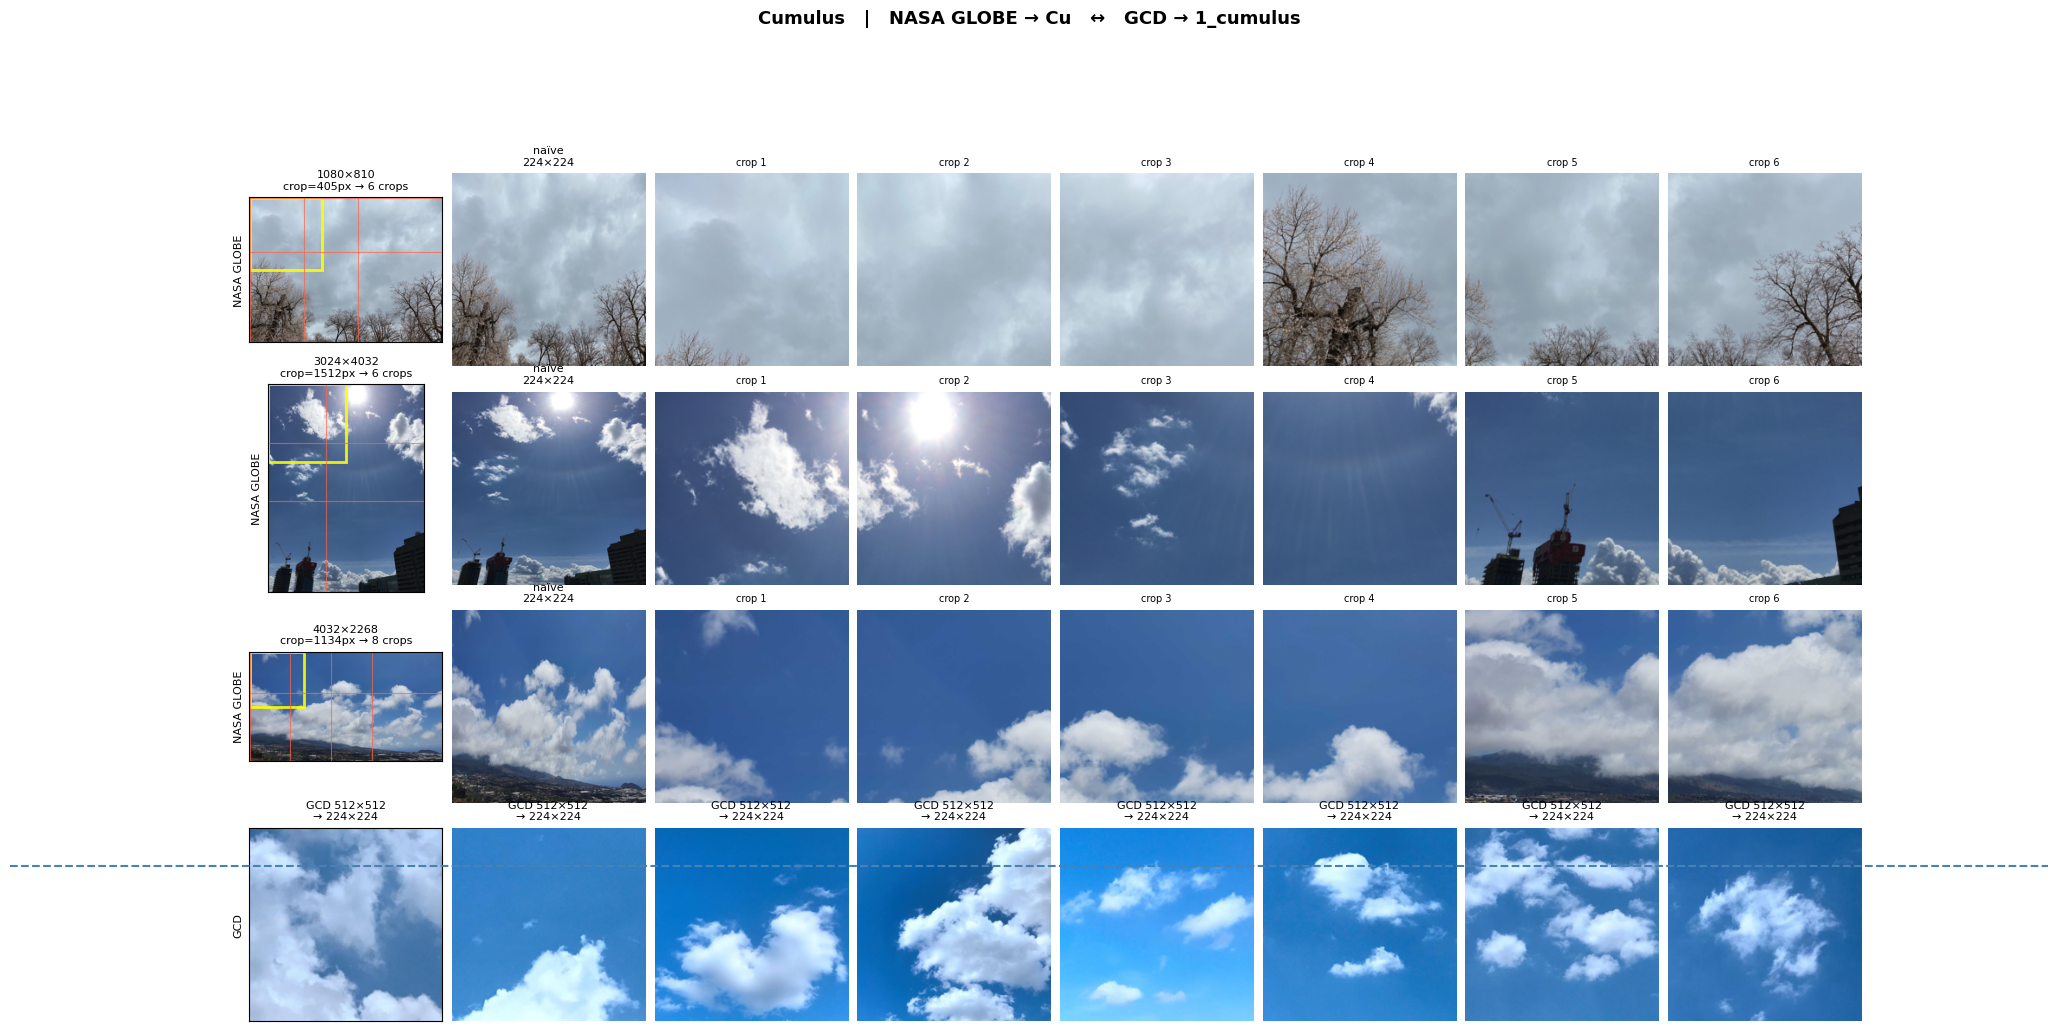

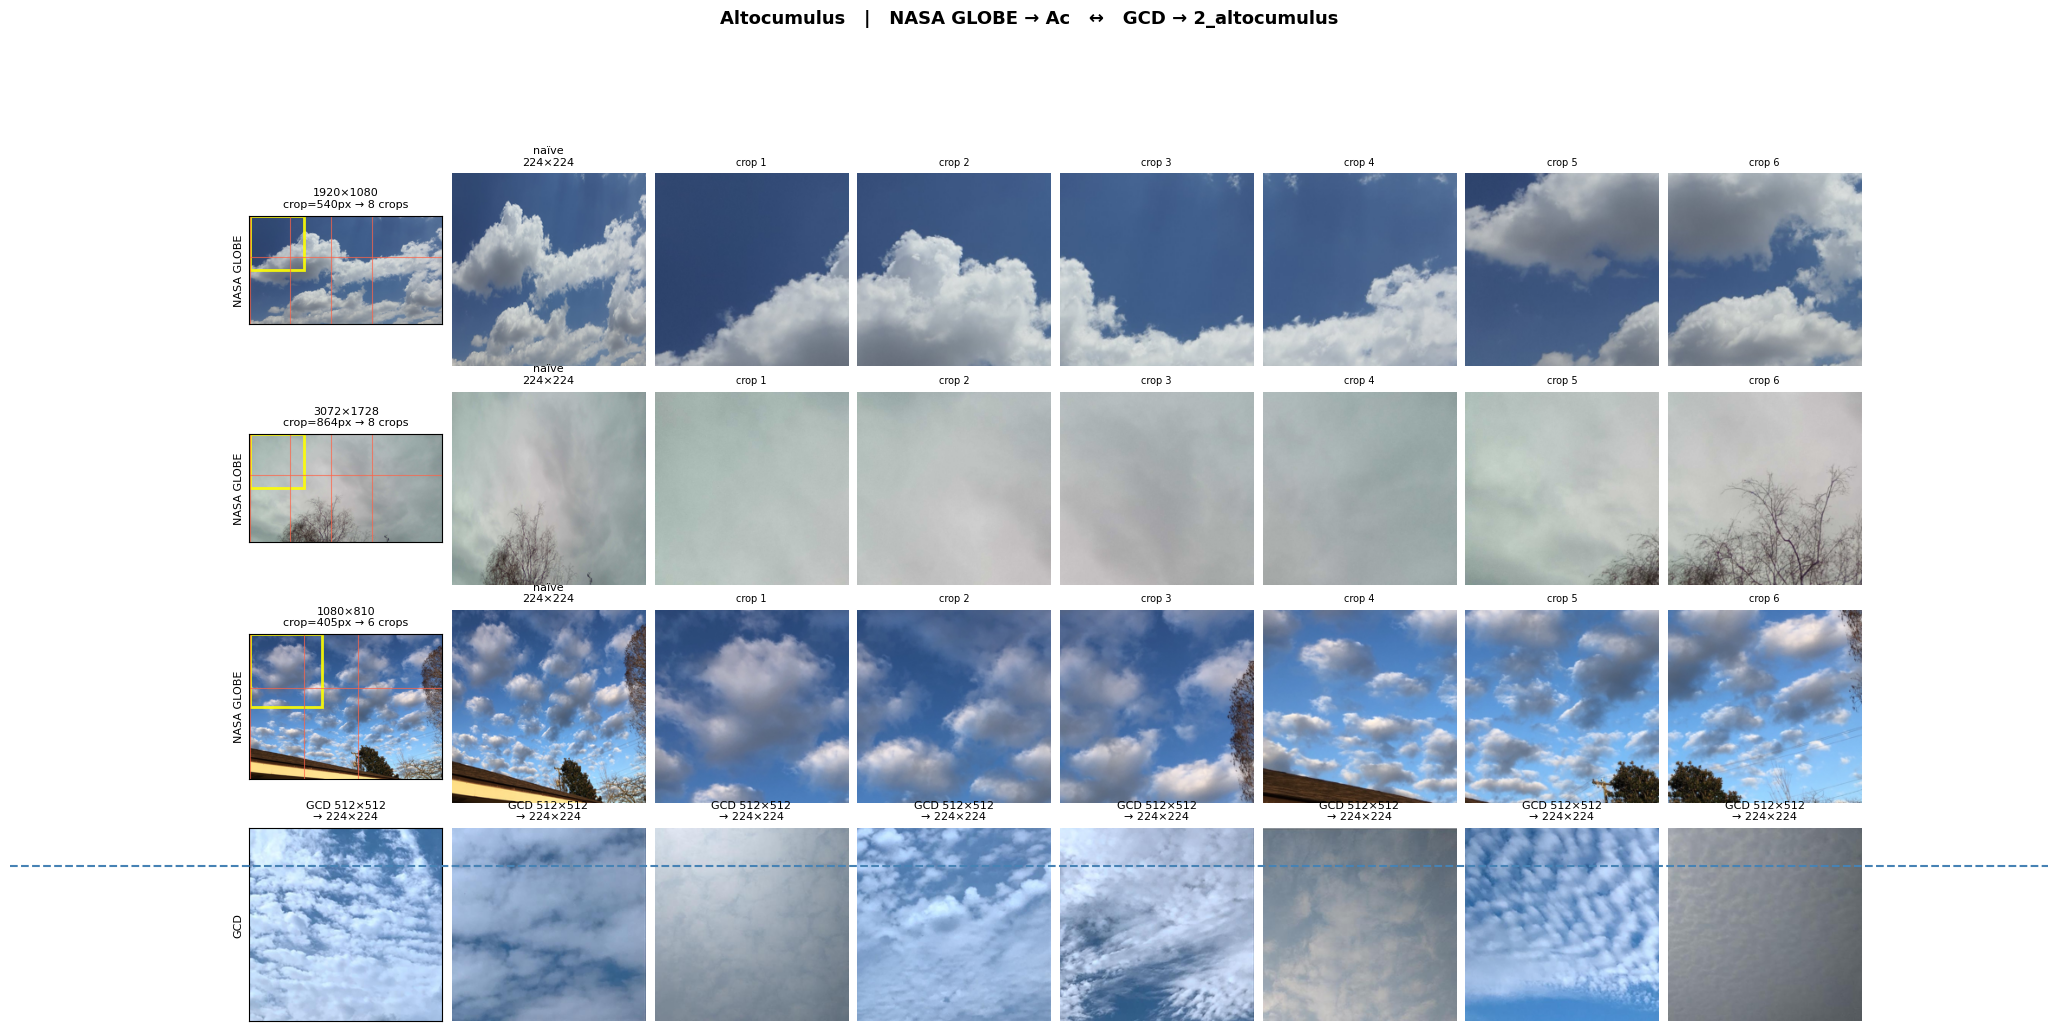

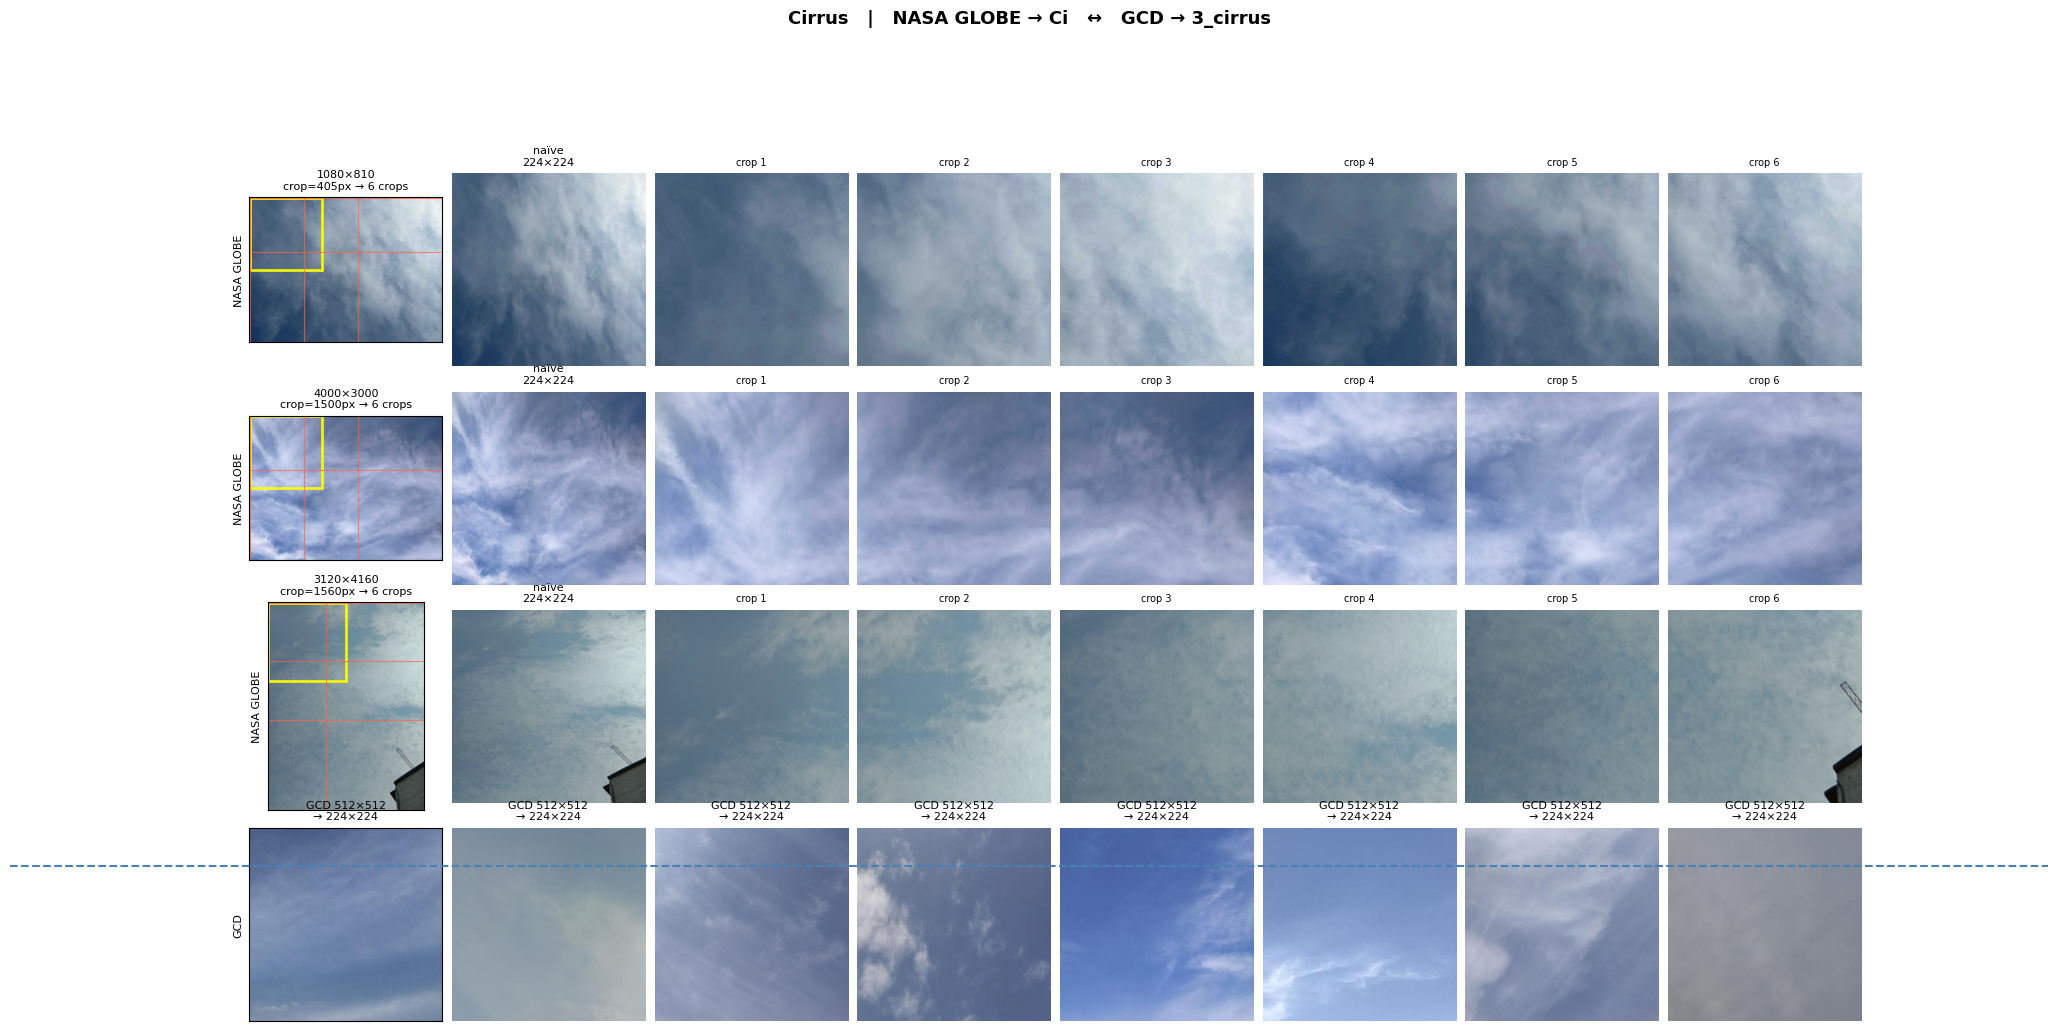

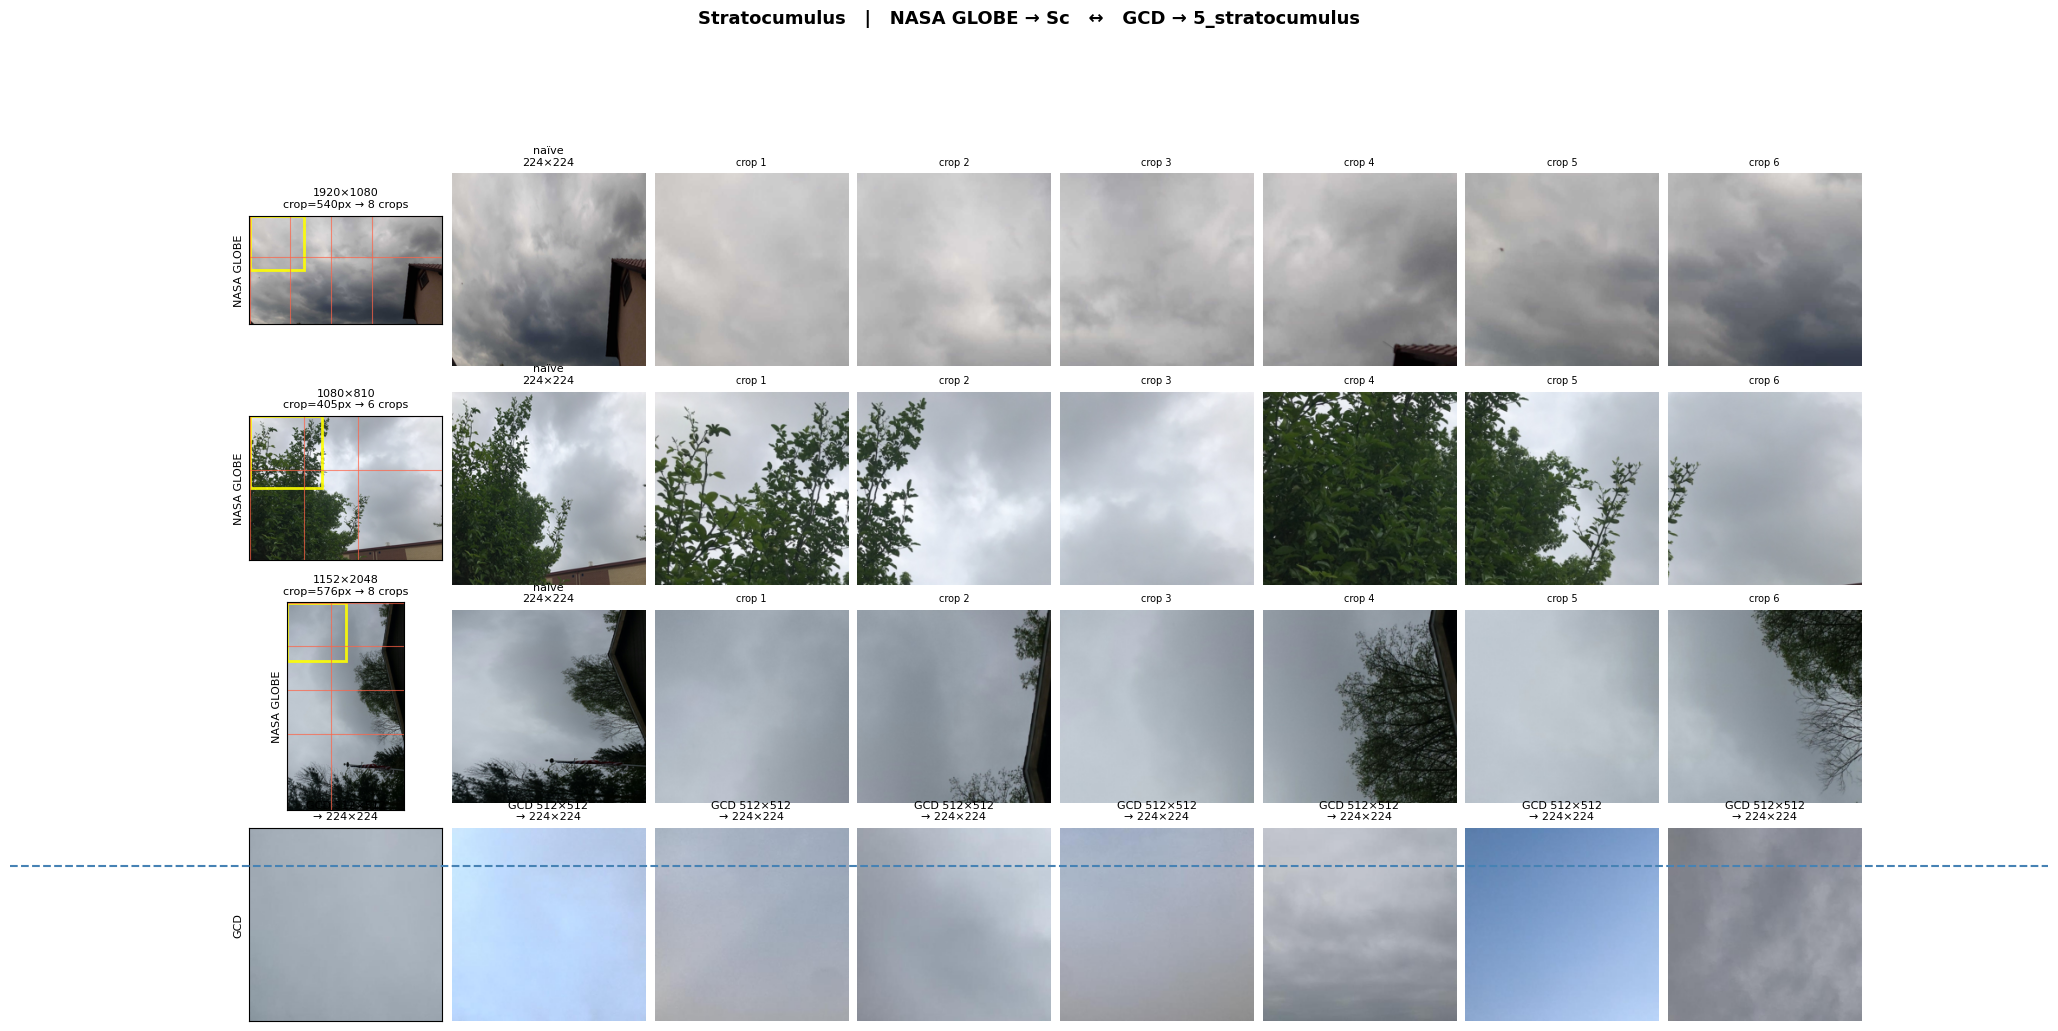

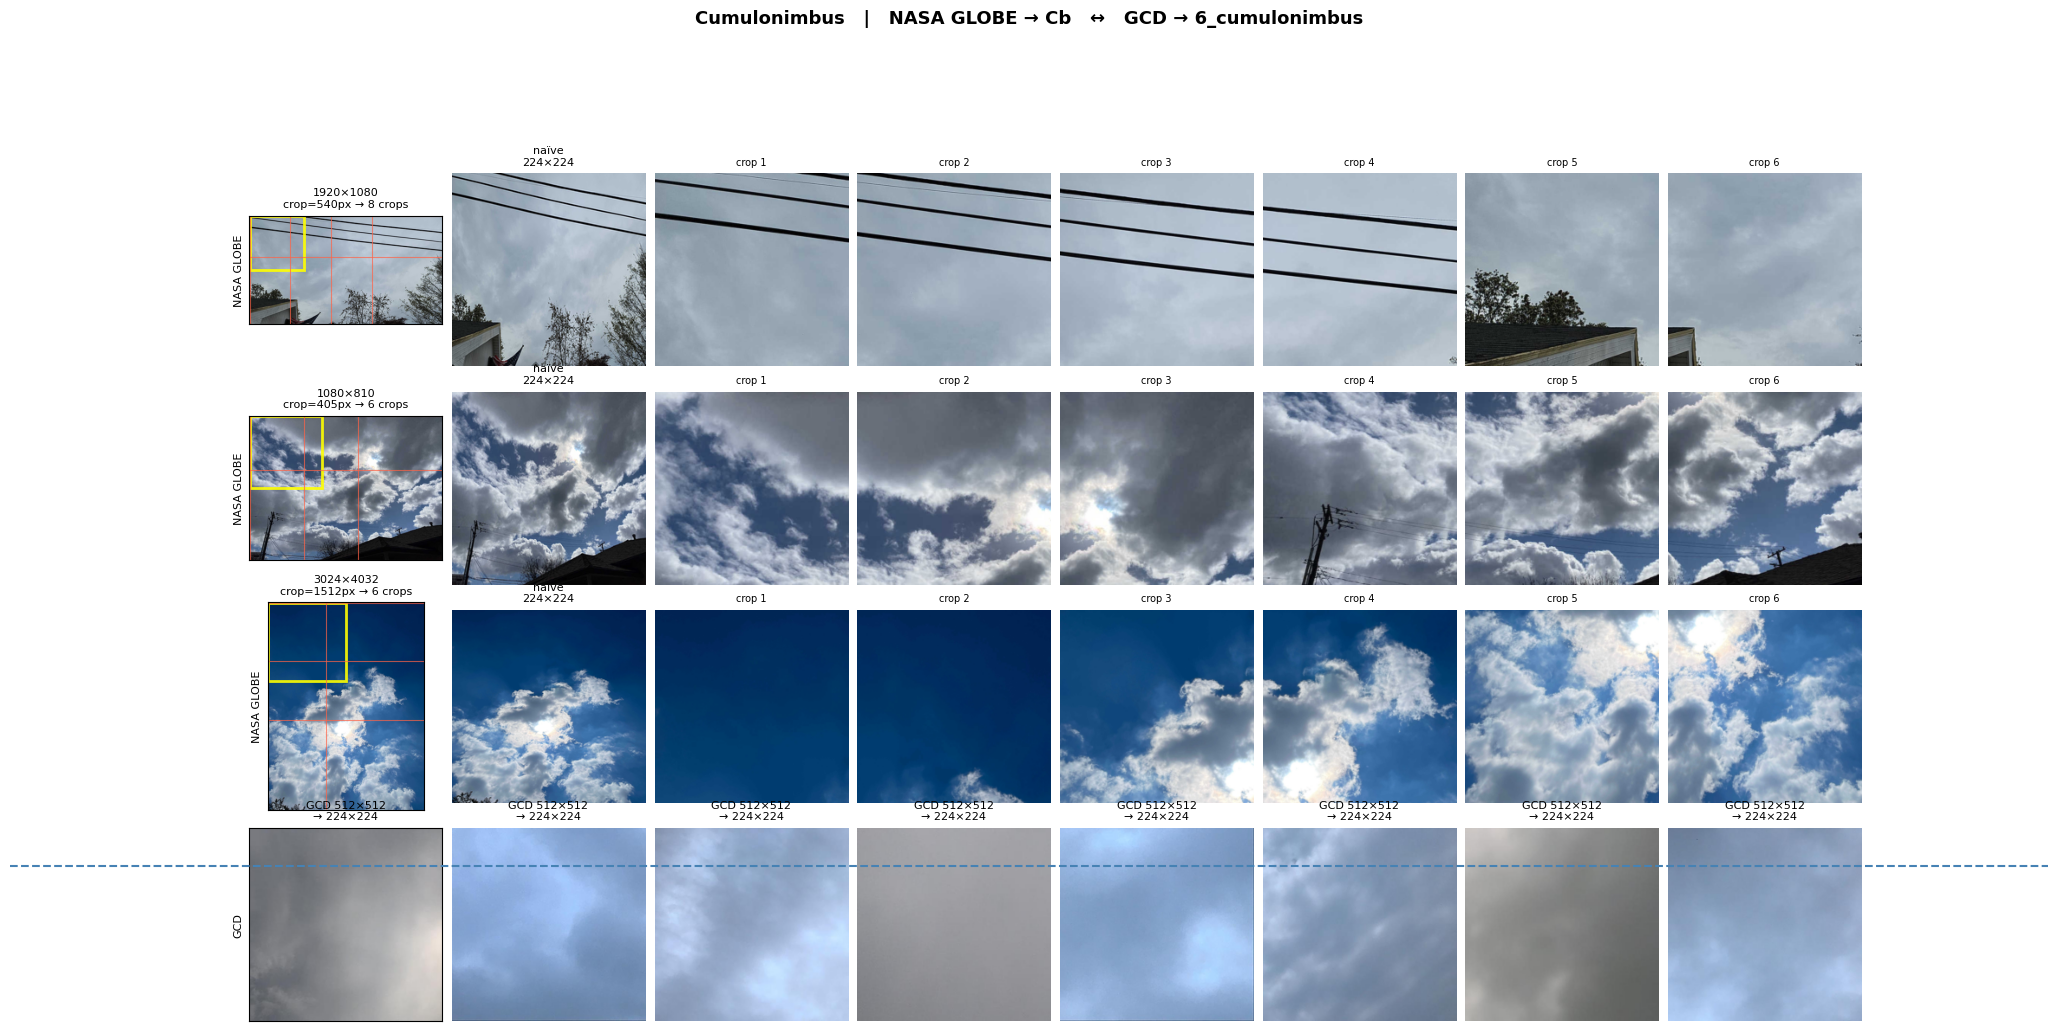

In [11]:
MAX_CROPS_SHOWN = 6    # crop columns to display per NASA image
N_GCD_SHOWN     = 8    # GCD samples in the bottom row
N_NASA_IMGS     = 3    # NASA images per class (varied resolution)
CROP_FRACTION   = 0.5  # crop side = 50% of the shorter image dimension
OVERLAP         = 0.25 # 25% overlap between adjacent crops

N_COLS = 1 + 1 + MAX_CROPS_SHOWN   # thumbnail + naive resize + crops = 8

for gcd_cls, nasa_cls, label in CLASS_PAIRS:
    nasa_folder = os.path.join(NASA_ROOT, nasa_cls)
    if not os.path.isdir(nasa_folder):
        print(f'Skipping {label}: {nasa_folder} not found')
        continue

    nasa_paths = pick_varied_res(nasa_folder, n=N_NASA_IMGS)
    gcd_imgs   = pick_gcd(gcd_cls, n=N_GCD_SHOWN)

    n_nasa = len(nasa_paths)
    n_rows = n_nasa + 1

    fig, axes = plt.subplots(
        n_rows, N_COLS,
        figsize=(N_COLS * 2.6, n_rows * 2.8),
        gridspec_kw={'hspace': 0.05, 'wspace': 0.05}
    )
    axes = np.atleast_2d(axes)

    # ── NASA rows ──────────────────────────────────────────────────────────
    for ri, path in enumerate(nasa_paths):
        img = Image.open(path)
        w, h = img.size
        crop_size, stride = crop_params(w, h, CROP_FRACTION, OVERLAP)
        crops = get_crops(path, output_size=CROP_SIZE,
                          crop_fraction=CROP_FRACTION, overlap=OVERLAP)
        thumb, vlines, hlines, crop_rect, total = make_thumbnail_with_grid(
            img, CROP_FRACTION, OVERLAP)

        # Col 0: thumbnail with stride grid + first-crop extent rectangle
        ax = axes[ri, 0]
        ax.imshow(thumb)
        for x in vlines:
            ax.axvline(x, color='tomato', lw=0.8, alpha=0.7)
        for y in hlines:
            ax.axhline(y, color='tomato', lw=0.8, alpha=0.7)
        ax.add_patch(Rectangle(
            (crop_rect[0], crop_rect[1]),
            crop_rect[2] - crop_rect[0], crop_rect[3] - crop_rect[1],
            linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.9
        ))
        ax.set_title(f'{w}×{h}\ncrop={crop_size}px → {total} crops', fontsize=8)
        ax.set_ylabel('NASA GLOBE', fontsize=8)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # Col 1: naive resize to 224×224 (current approach)
        ax = axes[ri, 1]
        ax.imshow(img.resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS))
        ax.set_title('naïve\n224×224', fontsize=8)
        ax.axis('off')

        # Cols 2–7: proportional crops (resized to 224×224)
        for ci in range(MAX_CROPS_SHOWN):
            ax = axes[ri, 2 + ci]
            if ci < len(crops):
                ax.imshow(crops[ci])
                ax.set_title(f'crop {ci + 1}', fontsize=7)
                ax.axis('off')
            else:
                ax.set_visible(False)

    # ── GCD row ────────────────────────────────────────────────────────────
    gcd_row = n_nasa
    for gi in range(N_COLS):
        ax = axes[gcd_row, gi]
        if gi < len(gcd_imgs):
            ax.imshow(gcd_imgs[gi].resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS))
            if gi == 0:
                ax.set_title('GCD 512×512\n→ 224×224', fontsize=8)
                ax.set_ylabel('GCD', fontsize=8)
                ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            else:
                ax.set_title('GCD 512×512\n→ 224×224', fontsize=8)
                ax.axis('off')
        else:
            ax.set_visible(False)

    fig.add_artist(plt.Line2D(
        [0.01, 0.99], [1 / n_rows + 0.005, 1 / n_rows + 0.005],
        transform=fig.transFigure, color='steelblue', linewidth=1.5, linestyle='--'
    ))
    fig.suptitle(
        f'{label}   |   NASA GLOBE → {nasa_cls}   ↔   GCD → {gcd_cls}',
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

In [12]:
# ── Find the largest images across all classes in NASA_ROOT ──────────────────

from pathlib import Path

print('Scanning for image sizes...')
records = []  # (w*h, w, h, path, class_folder)
for cls_dir in sorted(Path(NASA_ROOT).iterdir()):
    if not cls_dir.is_dir():
        continue
    for p in cls_dir.iterdir():
        if p.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        try:
            w, h = Image.open(p).size
            records.append((w * h, w, h, p, cls_dir.name))
        except Exception:
            pass

records.sort(reverse=True)
print(f'Scanned {len(records):,} images.')
print(f'Largest: {records[0][1]}×{records[0][2]}  ({records[0][4]}/{records[0][3].name})')
print(f'Smallest: {records[-1][1]}×{records[-1][2]}  ({records[-1][4]}/{records[-1][3].name})')

Scanning for image sizes...
Scanned 30,000 images.
Largest: 9248×6936  (St/116-213144-68652784-202305201634_GE_St.jpg)
Smallest: 128×96  (Ns/116-126615-3452982-201903280612_GE_Ns.jpg)


IndexError: index 7 is out of bounds for axis 0 with size 7

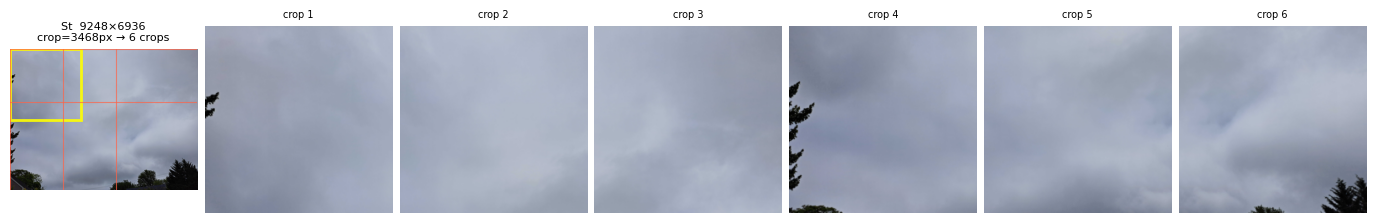

In [13]:
# ── Crop and display the N largest images ────────────────────────────────────

TOP_N         = 8   # how many of the largest images to show
MAX_CROPS_BIG = 8   # max crop cols displayed per image

for _, w, h, path, cls in records[:TOP_N]:
    crop_size, stride = crop_params(w, h, CROP_FRACTION, OVERLAP)
    crops = get_crops(str(path), output_size=CROP_SIZE,
                      crop_fraction=CROP_FRACTION, overlap=OVERLAP)
    img = Image.open(path)
    thumb, vlines, hlines, crop_rect, total = make_thumbnail_with_grid(
        img, CROP_FRACTION, OVERLAP, max_w=360)

    n_cols = 1 + min(len(crops), MAX_CROPS_BIG)
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 2.5, 3.2),
                             gridspec_kw={'wspace': 0.04})
    axes = np.atleast_1d(axes)

    # Col 0: thumbnail with stride grid + first-crop extent
    axes[0].imshow(thumb)
    for x in vlines:
        axes[0].axvline(x, color='tomato', lw=0.8, alpha=0.7)
    for y in hlines:
        axes[0].axhline(y, color='tomato', lw=0.8, alpha=0.7)
    axes[0].add_patch(Rectangle(
        (crop_rect[0], crop_rect[1]),
        crop_rect[2] - crop_rect[0], crop_rect[3] - crop_rect[1],
        linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.9
    ))
    axes[0].set_title(f'{cls}  {w}×{h}\ncrop={crop_size}px → {total} crops', fontsize=8)
    axes[0].axis('off')

    # Remaining cols: crops
    for ci in range(MAX_CROPS_BIG):
        ax = axes[1 + ci]
        if ci < len(crops):
            ax.imshow(crops[ci])
            ax.set_title(f'crop {ci + 1}', fontsize=7)
        else:
            ax.set_visible(False)
        ax.axis('off')

    fig.suptitle(path.name, fontsize=8, color='#555', y=1.0)
    plt.tight_layout()
    plt.show()

## Observations to look for

| Question | What to look at |
|---|---|
| Do crops look like GCD images? | Compare cols 2–7 (NASA crops) with the GCD row |
| How much does naïve resize lose? | Col 1 vs cols 2–7 — does squishing the full image destroy texture? |
| Do high-res images give better crops? | Compare crops from 4032×3024 vs 1080×810 thumbnails |
| Are there blank/uninformative crops? | Sky-only or ground-only patches — edge cases to handle in training |

### Next steps (if hypothesis holds)
- Replace the single-image DataLoader with a **patch DataLoader**: for each image, yield all non-overlapping 224×224 crops as separate training samples
- Optionally filter out near-uniform (sky/ground-only) patches by variance threshold
- Consider overlapping crops (stride < 224) for denser coverage of larger images